# Entrega 1 - PLN | Modelo de clasificación de reseñas de Amazon en español

## Experimento 1: cinco estrellas · Experimento 2: tres sentimientos

**Curso:** Procesamiento del lenguaje natural  
**Autor(es):**  
- Camilo Camero
- Andres Cuellar
- Andres Gonzalez
- Julian Salamanca



## 1. ¿Cuál es el problema que queremos resolver?

Hoy en día, las tiendas online como Amazon reciben miles y miles de reseñas. Leerlas una por una es imposible. Si logramos automatizar esto, podemos saber rápidamente si los clientes están felices o enojados, y detectar problemas a tiempo.

**Nuestro objetivo:** Vamos a probar dos formas de analizar estas reseñas:
- **Experimento 1:** Intentaremos que el modelo adivine exactamente cuántas estrellas (del 1 al 5) le dio el usuario.
- **Experimento 2:** Algo más sencillo. Agruparemos las reseñas en 3 sentimientos: Negativo, Neutral y Positivo.

### Definición de las dos variables objetivo

| Etiqueta original | Estrellas | Experimento 1 | Experimento 2 | ID sentimiento |
|---:|---:|---|---|---:|
| 0 | 1 | 1 estrella | Negativo | 0 |
| 1 | 2 | 2 estrellas | Negativo | 0 |
| 2 | 3 | 3 estrellas | Neutral | 1 |
| 3 | 4 | 4 estrellas | Positivo | 2 |
| 4 | 5 | 5 estrellas | Positivo | 2 |

La calificación funciona como una **aproximación al sentimiento**. No es una anotación lingüística independiente: una reseña puede mezclar elogios y críticas o asignar estrellas que no coinciden completamente con su texto.


## 2. Preparando nuestro equipo de trabajo

Primero, instalamos y traemos todas las herramientas que vamos a necesitar. Usaremos cosas clásicas y también librerías potentes como spaCy (para entender el texto) y PyTorch Lightning (para construir nuestras redes neuronales).

In [1]:
%pip install -q datasets lightning torchmetrics scikit-learn seaborn spacy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 28.9 MB/s eta 0:00:00


In [2]:
# Modelo mediano de spaCy en español; se usa solo en la exploración de embeddings.
!python -m spacy download es_core_news_md -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 14.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import os
import re
import time
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from datasets import load_dataset
from IPython.display import Markdown, display

import spacy
from scipy.spatial.distance import cosine

import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset, DataLoader

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
L.seed_everything(SEED, workers=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

print(f"Dispositivo: {DEVICE}")
print(f"PyTorch: {torch.__version__}")


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Dispositivo: cuda
PyTorch: 2.11.0+cu128


## 3. Cargando los datos (Las reseñas)

Este dataset contiene un total de 200 mil reseñas de entrenamiento, 5 mil de validacion y otras 5 mil para test. DDecidimos bajar el dataset por medio de la URL proporcionada por Hugging Face; por lo tanto, la reproducibilidad del taller está ligada a la disponibilidad de esa fuente.

Respetamos estas separaciones oficiales para que el modelo no haga trampa estudiando las preguntas del examen final.

In [4]:
BASE_URL = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/"
DATA_FILES = {
    "train": BASE_URL + "train.jsonl",
    "validation": BASE_URL + "validation.jsonl",
    "test": BASE_URL + "test.jsonl",
}

raw_dataset = load_dataset("json", data_files=DATA_FILES)
raw_dataset


es/train.jsonl: reconstructing file:   0%|          |  0.00B / 48.7MB            

es/train.jsonl: downloading bytes:           |  0.00B            

validation.jsonl:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})

In [5]:
def prepare_frame(split):
    frame = split.to_pandas()[["id", "text", "label"]].copy()
    frame["label"] = frame["label"].astype(int)
    frame["stars"] = frame["label"] + 1
    frame["sentiment"] = np.select(
        [frame["label"] <= 1, frame["label"] == 2],
        [0, 1],
        default=2,
    ).astype(int)
    return frame

full_train_df = prepare_frame(raw_dataset["train"])
full_val_df = prepare_frame(raw_dataset["validation"])
full_test_df = prepare_frame(raw_dataset["test"])

for name, frame in {
    "Entrenamiento": full_train_df,
    "Validación": full_val_df,
    "Prueba": full_test_df,
}.items():
    print(f"{name:>13}: {len(frame):>7,} | {frame['label'].value_counts().sort_index().to_dict()}")

display(full_train_df.head())


Entrenamiento: 200,000 | {0: 40000, 1: 40000, 2: 40000, 3: 40000, 4: 40000}
   Validación:   5,000 | {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}
       Prueba:   5,000 | {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}


,id,text,label,stars,sentiment
0,es_0491108,television Nevir\n\nNada bueno se me fue ka pa...,0,1,0
1,es_0869872,Dinero tirado a la basura con esta compra\n\nH...,0,1,0
2,es_0811721,solo llega una unidad cuando te obligan a comp...,0,1,0
3,es_0359921,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,0,1,0
4,es_0068940,Devuelto\n\nLlega tarde y co la talla equivocada,0,1,0


### Las reglas del juego para comparar justamente

Como en el segundo experimento vamos a agrupar estrellas (por ejemplo, 1 y 2 estrellas se vuelven "Negativo"), las categorías nos quedarían desbalanceadas. Para que la pelea sea justa entre ambos experimentos, decidimos usar exactamente la misma cantidad de datos:
- **Entrenamiento:** 5.000 reseñas por cada estrella (25.000 en total).
- **Validación y Prueba:** Las mismas 5.000 oficiales.

Asimismo, decidimos usar solo 5.000 por estrella pensando en la cantidad de experimentos que íbamos a correr: al ser 2 tareas con 4 entrenamientos de LSTM/BiLSTM (más los reintentos normales de ajustar hiperparámetros), entrenar con el dataset completo habría multiplicado el tiempo de cómputo varias veces, dificultando iterar y comparar tantos modelos dentro del tiempo del curso.

In [6]:
TRAIN_PER_STAR = 5_000

blocked_texts = set(full_val_df["text"]) | set(full_test_df["text"])
eligible_train = (
    full_train_df.drop_duplicates(subset="text")
    .loc[lambda frame: ~frame["text"].isin(blocked_texts)]
    .copy()
)

train_df = pd.concat([
    group.sample(n=TRAIN_PER_STAR, random_state=SEED)
    for _, group in eligible_train.groupby("label")
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

val_df = full_val_df.reset_index(drop=True).copy()
test_df = full_test_df.reset_index(drop=True).copy()

STAR_NAMES = ["1 estrella", "2 estrellas", "3 estrellas", "4 estrellas", "5 estrellas"]
SENTIMENT_NAMES = ["Negativo", "Neutral", "Positivo"]

sample_summary = pd.DataFrame({
    "Estrellas_train": train_df["label"].value_counts().sort_index(),
    "Estrellas_val": val_df["label"].value_counts().sort_index(),
    "Estrellas_test": test_df["label"].value_counts().sort_index(),
})
display(sample_summary)

sentiment_summary = pd.DataFrame({
    "Sentimiento_train": train_df["sentiment"].value_counts().sort_index(),
    "Sentimiento_val": val_df["sentiment"].value_counts().sort_index(),
    "Sentimiento_test": test_df["sentiment"].value_counts().sort_index(),
})
sentiment_summary.index = SENTIMENT_NAMES
display(sentiment_summary)


,Estrellas_train,Estrellas_val,Estrellas_test
label,,,
0,5000,1000,1000
1,5000,1000,1000
2,5000,1000,1000
3,5000,1000,1000
4,5000,1000,1000


,Sentimiento_train,Sentimiento_val,Sentimiento_test
Negativo,10000,2000,2000
Neutral,5000,1000,1000
Positivo,10000,2000,2000


## 4. Echando un vistazo a los datos (Análisis exploratorio)

Antes de meterle inteligencia artificial a esto, siempre es bueno conocer qué tenemos entre manos. Vamos a revisar qué tan largos son los textos, si hay palabras raras y cómo se ven nuestras dos formas de clasificar (5 estrellas vs 3 sentimientos).

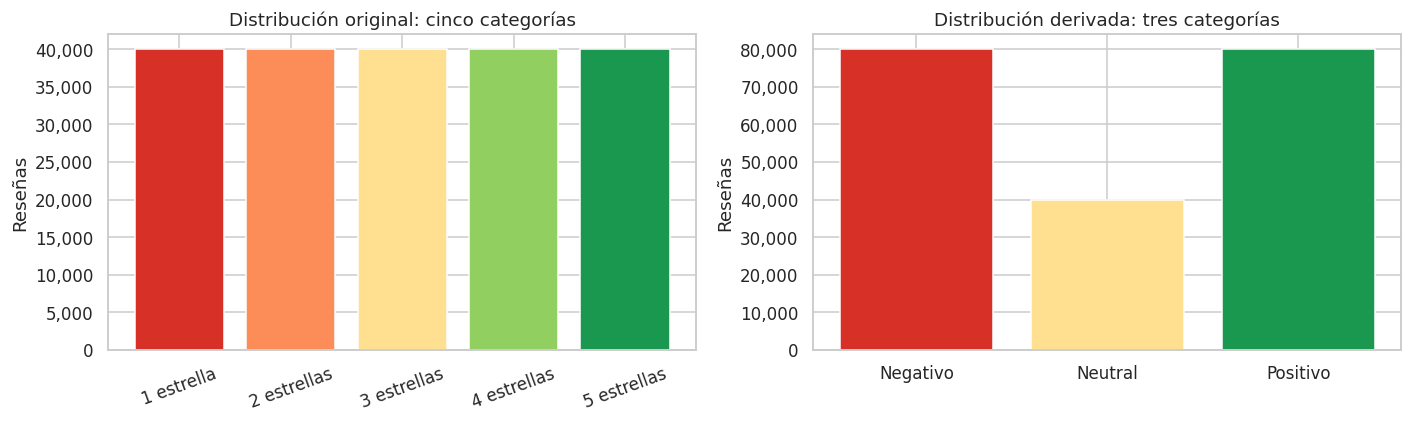

In [7]:
STAR_COLORS = ["#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
star_counts = full_train_df["label"].value_counts().sort_index()
sentiment_counts = full_train_df["sentiment"].value_counts().sort_index()

axes[0].bar(STAR_NAMES, star_counts.values, color=STAR_COLORS)
axes[0].set_title("Distribución original: cinco categorías")
axes[0].set_ylabel("Reseñas")
axes[0].tick_params(axis="x", rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{int(value):,}"))

axes[1].bar(SENTIMENT_NAMES, sentiment_counts.values, color=[STAR_COLORS[0], STAR_COLORS[2], STAR_COLORS[4]])
axes[1].set_title("Distribución derivada: tres categorías")
axes[1].set_ylabel("Reseñas")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{int(value):,}"))

plt.tight_layout()
plt.show()


,n_chars,n_tokens
count,200000.00,200000.00
mean,172.47,31.16
std,135.99,24.84
min,22.00,3.00
50%,140.00,25.00
75%,210.00,38.00
90%,322.00,59.00
95%,419.00,76.00
99%,699.00,127.00
max,3162.00,566.00


,mean,median,max
stars,,,
1,32.1,26.0,414
2,35.0,28.0,511
3,32.3,26.0,466
4,29.0,24.0,390
5,27.4,22.0,566


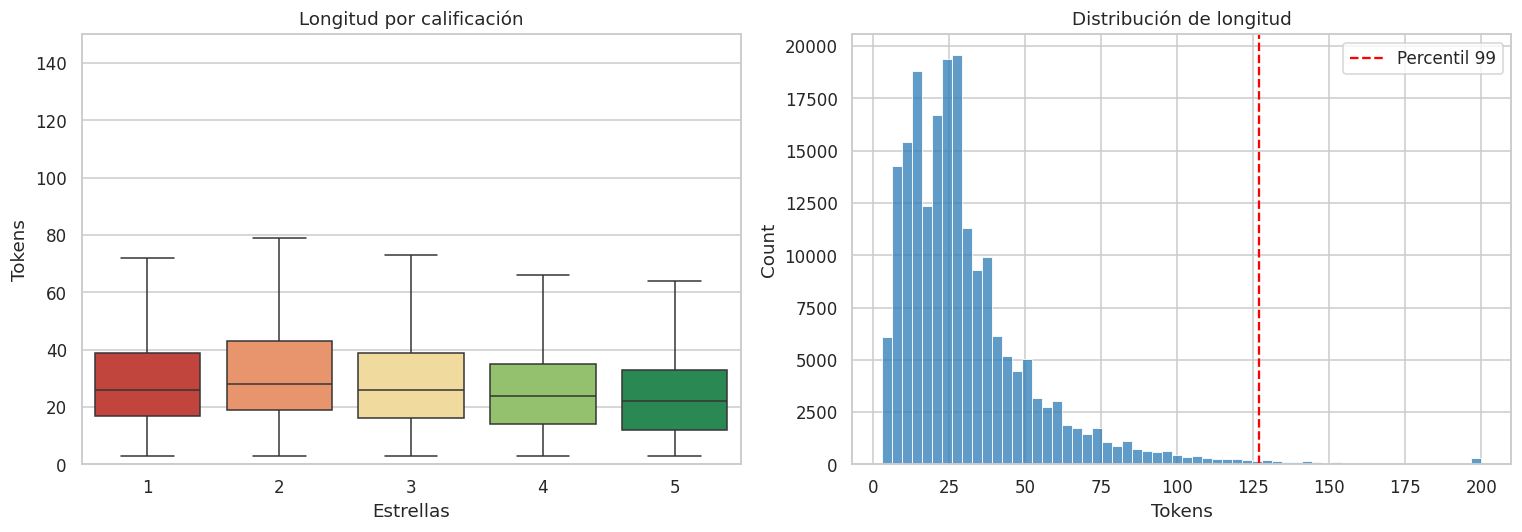

In [8]:
TOKEN_PATTERN = re.compile(r"[a-záéíóúüñ0-9]+", flags=re.IGNORECASE)

def simple_tokenizer(text):
    return TOKEN_PATTERN.findall(str(text).lower())

full_train_df["n_chars"] = full_train_df["text"].str.len()
full_train_df["n_tokens"] = full_train_df["text"].map(lambda text: len(simple_tokenizer(text)))

length_stats = full_train_df[["n_chars", "n_tokens"]].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)
display(length_stats)

by_star = full_train_df.groupby("stars")["n_tokens"].agg(["mean", "median", "max"]).round(1)
display(by_star)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=full_train_df, x="stars", y="n_tokens", showfliers=False, palette=STAR_COLORS, ax=axes[0])
axes[0].set_ylim(0, 150)
axes[0].set_title("Longitud por calificación")
axes[0].set_xlabel("Estrellas")
axes[0].set_ylabel("Tokens")

sns.histplot(full_train_df["n_tokens"].clip(upper=200), bins=60, color="#2c7bb6", ax=axes[1])
axes[1].axvline(full_train_df["n_tokens"].quantile(0.99), color="red", linestyle="--", label="Percentil 99")
axes[1].set_title("Distribución de longitud")
axes[1].set_xlabel("Tokens")
axes[1].legend()

plt.tight_layout()
plt.show()


Estas tablas y gráficas representan el análisis de la longitud de los textos (cuántas palabras escribe la gente)
si miramos la tabla de la division de las estrellas y la comparamos con la grafica de cajas y bigotes vemos lo siguiente:
- 5 estrellas (Los más cortos): Tienen la mediana más baja (22 palabras). Cuando a alguien le gusta un producto, no necesita dar explicaciones. Solo escribe "Excelente producto, llegó a tiempo, recomendado" y listo.
- 2 y 3 estrellas (Los más largos): Tienen las medianas más altas (28 y 26 palabras). Las cajas de la gráfica también se ven más "estiradas" hacia arriba. Esto pasa porque la gente que da calificaciones intermedias o malas suele escribir mucho más para justificar su enojo o dar detalles mixtos: "El material se siente de buena calidad, pero la caja llegó aplastada, además el manual viene en chino y me tocó buscar un tutorial...".

### ¿Qué tan largas dejamos las reseñas?

Decidimos cortar los textos largos y dejar un máximo de **128 palabras (tokens)**. ¿Por qué?
- Porque la gran mayoría de la gente escribe reseñas cortas (unas 25 palabras).
- El 99% de las reseñas tienen menos de 127 palabras.
- Cortar en 128 nos permite no perder casi nada de información y hace que el modelo entrene mucho más rápido.

In [9]:
MAX_LENGTH = 128
length_percentiles = np.percentile(full_train_df["n_tokens"], [50, 75, 90, 95, 99])
coverage = (full_train_df["n_tokens"] <= MAX_LENGTH).mean()

for percentile, value in zip([50, 75, 90, 95, 99], length_percentiles):
    print(f"P{percentile}: {value:.0f} tokens")
print(f"Cobertura con MAX_LENGTH={MAX_LENGTH}: {coverage:.2%}")


P50: 25 tokens
P75: 38 tokens
P90: 59 tokens
P95: 76 tokens
P99: 127 tokens
Cobertura con MAX_LENGTH=128: 99.06%


### Limpiando la casa (Calidad de datos)

Aquí revisamos que no haya textos vacíos o reseñas repetidas. Afortunadamente, cuando sacamos nuestra muestra para entrenar, ya nos aseguramos de quitar cualquier texto duplicado o que se haya colado en los datos de prueba.

In [10]:
quality = pd.Series({
    "Nulos en entrenamiento original": full_train_df["text"].isna().sum(),
    "Duplicados internos originales": full_train_df["text"].duplicated().sum(),
    "Textos con menos de 3 tokens": (full_train_df["n_tokens"] < 3).sum(),
    "Coincidencias train-validation": full_train_df["text"].isin(set(full_val_df["text"])).sum(),
    "Coincidencias train-test": full_train_df["text"].isin(set(full_test_df["text"])).sum(),
}, name="Cantidad")
display(quality.to_frame())


,Cantidad
Nulos en entrenamiento original,0
Duplicados internos originales,274
Textos con menos de 3 tokens,0
Coincidencias train-validation,20
Coincidencias train-test,32


### ¿Cuáles son las palabras estrella? (Ley de Zipf)

Como pasa siempre al hablar, usamos mucho palabras como "el", "la", "de", pero esas no nos dicen si alguien está feliz o enojado. Para ver qué palabras realmente marcan la diferencia, hicimos una gráfica comparando qué dice la gente cuando da 1 estrella vs cuando da 5 estrellas.

*Ojo:* Para esta gráfica quitamos las palabras comunes (stopwords). Pero para entrenar a nuestro modelo **sí dejamos la palabra "no"**. ¡Imagínate lo que pasaría si el modelo lee "funciona" en lugar de "no funciona"! Cambia todo el sentido.

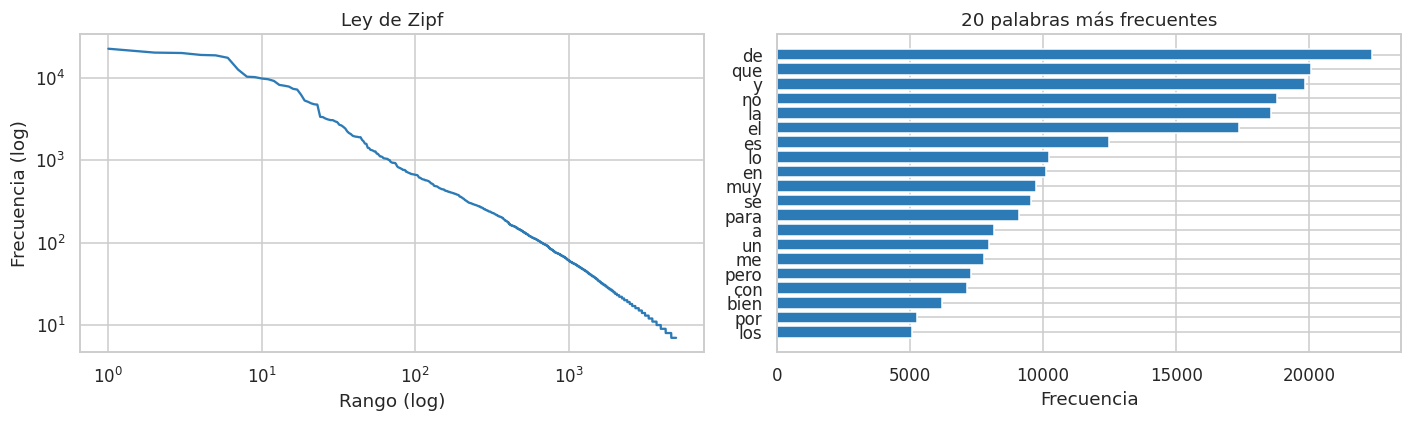

In [11]:
sample_eda = train_df.sample(min(20_000, len(train_df)), random_state=SEED)
token_counts_eda = Counter()
for text in sample_eda["text"]:
    token_counts_eda.update(simple_tokenizer(text))

frequencies = np.array(sorted(token_counts_eda.values(), reverse=True))
ranks = np.arange(1, len(frequencies) + 1)
top_words = token_counts_eda.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].loglog(ranks[:5_000], frequencies[:5_000], color="#2c7bb6")
axes[0].set_title("Ley de Zipf")
axes[0].set_xlabel("Rango (log)")
axes[0].set_ylabel("Frecuencia (log)")

words, counts = zip(*top_words)
axes[1].barh(list(words)[::-1], list(counts)[::-1], color="#2c7bb6")
axes[1].set_title("20 palabras más frecuentes")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()


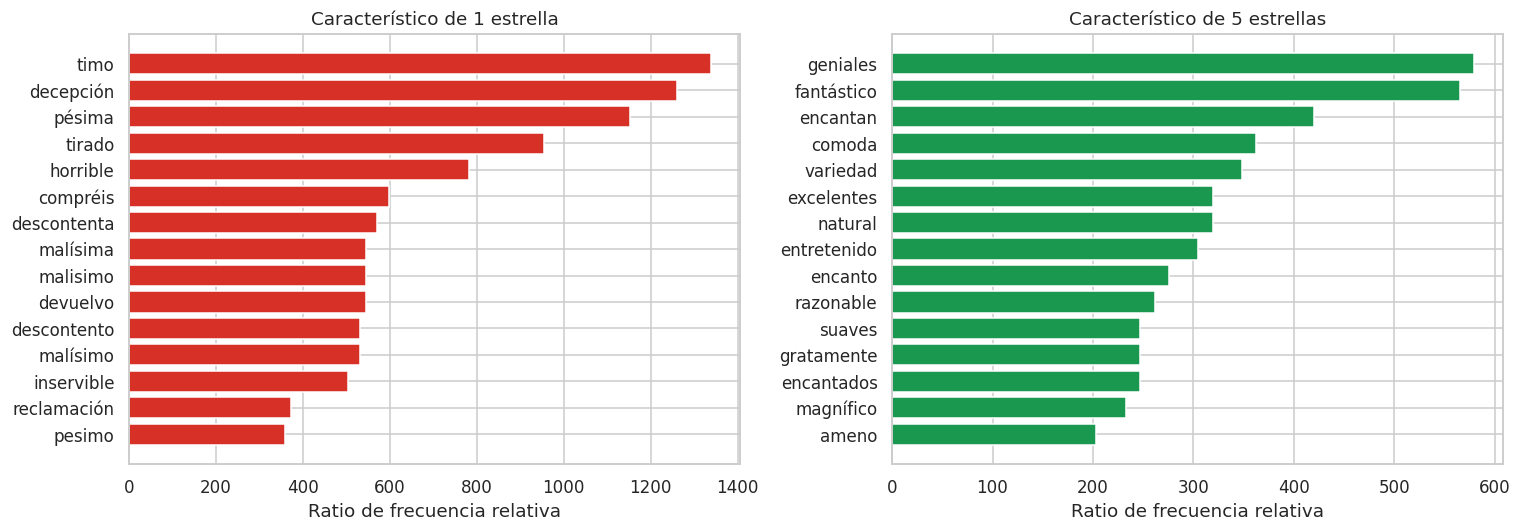

In [12]:
STOPWORDS_EDA = {
    "de", "la", "el", "en", "y", "a", "que", "es", "se", "del", "las", "los",
    "un", "una", "con", "por", "para", "lo", "le", "más", "pero", "mi", "me",
    "como", "muy", "al", "este", "esta", "su", "sus", "también", "si", "fue",
    "ha", "hay", "era", "ser", "he", "nos", "ya", "todo", "cuando", "bien",
    "solo", "estar", "tiene", "cada", "así", "hasta", "porque", "desde", "sobre"
}

def word_counter(frame):
    counter = Counter()
    for text in frame["text"]:
        counter.update(
            token for token in simple_tokenizer(text)
            if token not in STOPWORDS_EDA and len(token) > 3
        )
    return counter

negative_counter = word_counter(train_df[train_df["label"] == 0])
positive_counter = word_counter(train_df[train_df["label"] == 4])

def discriminative_words(source, comparison, n=15):
    source_total = sum(source.values())
    comparison_total = sum(comparison.values())
    scores = {
        word: (count / source_total + 1e-6) / (comparison[word] / comparison_total + 1e-6)
        for word, count in source.items()
        if count >= 6
    }
    return sorted(scores.items(), key=lambda item: item[1], reverse=True)[:n]

extreme_words = {
    "Característico de 1 estrella": discriminative_words(negative_counter, positive_counter),
    "Característico de 5 estrellas": discriminative_words(positive_counter, negative_counter),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, values), color in zip(axes, extreme_words.items(), [STAR_COLORS[0], STAR_COLORS[4]]):
    words, scores = zip(*values)
    ax.barh(list(words)[::-1], list(scores)[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("Ratio de frecuencia relativa")
plt.tight_layout()
plt.show()


## 5. Viendo si spaCy entiende nuestro español

Quisimos probar un modelo de lenguaje de spaCy (es_core_news_md) que ya viene "pre-entrenado" leyendo miles de noticias en español.
Queríamos ver qué tan bien se defiende leyendo reseñas de productos de Amazon (que tienen jerga, errores ortográficos y un lenguaje mucho más informal que una noticia).

Matriz de vectores spaCy: (20000, 300)


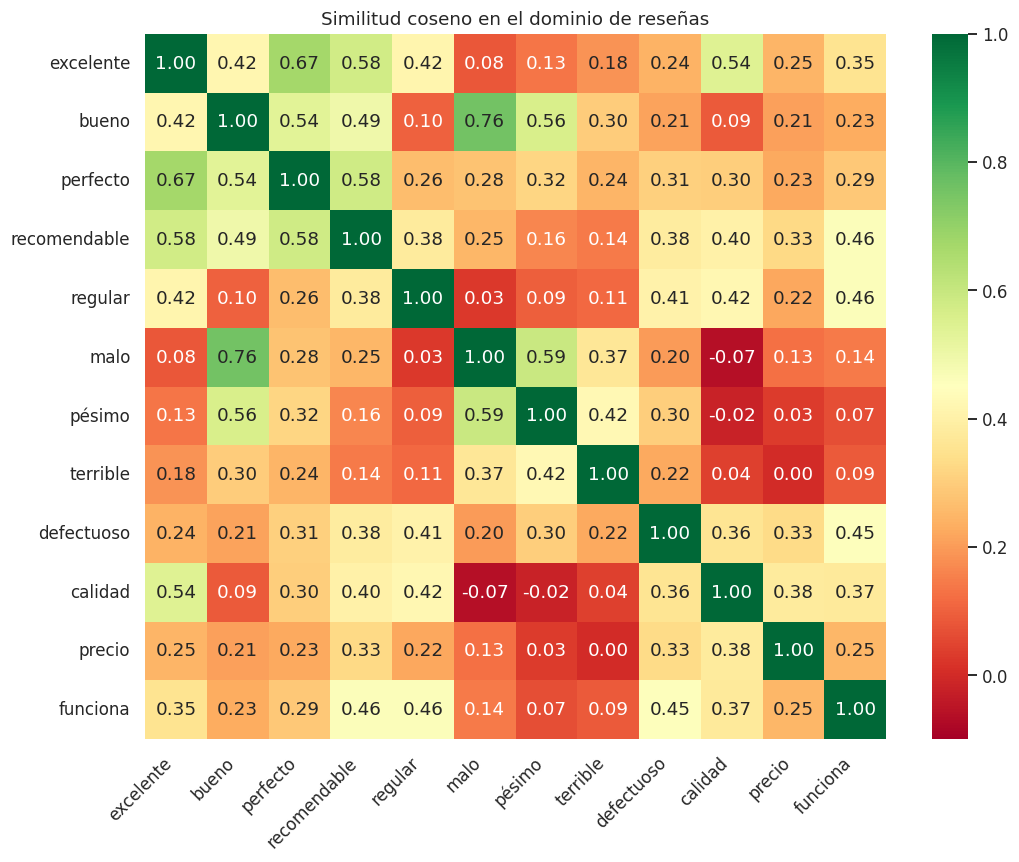

In [13]:
nlp = spacy.load("es_core_news_md")
print(f"Matriz de vectores spaCy: {nlp.vocab.vectors.shape}")

domain_words = [
    "excelente", "bueno", "perfecto", "recomendable",
    "regular", "malo", "pésimo", "terrible", "defectuoso",
    "calidad", "precio", "funciona",
]
available_words = [word for word in domain_words if nlp.vocab[word].has_vector]
vectors = {word: nlp.vocab[word].vector for word in available_words}
similarity_matrix = np.array([
    [1 - cosine(vectors[first], vectors[second]) for second in available_words]
    for first in available_words
])

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=available_words,
    yticklabels=available_words,
    cmap="RdYlGn",
    vmin=-0.1,
    vmax=1,
)
plt.title("Similitud coseno en el dominio de reseñas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Esta gráfica de calor nos muestra cómo el "cerebro" genérico de este modelo agrupa las palabras, revelando un problema que justifica este proyecto: aunque el modelo logra asociar lógicamente sinónimos como "excelente" y "perfecto", comete el grave error de creer que "bueno" y "malo" son casi idénticos (con una altísima similitud de 0.76). Esto ocurre porque las IAs pre-entrenadas aprenden deduciendo el contexto de las frases (por ejemplo, "el producto es muy bueno" vs "el producto es muy malo"); es decir, entienden la estructura gramatical, pero son completamente ciegas a la emoción humana. Es precisamente por esta tremenda confusión que no podemos depender de un modelo genérico de internet para leer reseñas, lo cual demuestra por qué fue estrictamente necesario construir y entrenar nuestra propia red neuronal para enseñarle a la máquina que, en el mundo de Amazon, "bueno" y "malo" son emociones totalmente opuestas.

In [14]:
sample_texts = train_df["text"].sample(500, random_state=SEED).tolist()
total_alpha = 0
out_of_vocabulary = 0
oov_examples = []

for document in nlp.pipe(sample_texts, disable=["parser", "ner"]):
    for token in document:
        if token.is_alpha:
            total_alpha += 1
            if token.is_oov:
                out_of_vocabulary += 1
                if len(oov_examples) < 20:
                    oov_examples.append(token.text)

print(f"Tokens alfabéticos: {total_alpha:,}")
print(f"Tasa OOV de spaCy: {out_of_vocabulary / max(total_alpha, 1):.2%}")
print("Ejemplos OOV:", sorted(set(oov_examples))[:15])

emoji_document = nlp("Son una 💩 y no las recomiendo")
display(pd.DataFrame([
    {
        "token": token.text,
        "tiene_vector": token.has_vector,
        "es_OOV": token.is_oov,
        "norma": token.vector_norm,
    }
    for token in emoji_document
]))


Tokens alfabéticos: 15,307
Tasa OOV de spaCy: 0.37%
Ejemplos OOV: ['AQUE', 'DABA', 'Devueltas', 'Dnd', 'INESTABLE', 'Invertid', 'Lamparita', 'Perfe', 'Poquísima', 'SEGUIDO', 'Tipicos', 'estafarme', 'gastate', 'hjo', 'iwatch']


,token,tiene_vector,es_OOV,norma
0,Son,True,False,52.749073
1,una,True,False,51.641262
2,💩,True,False,61.733624
3,y,True,False,43.300953
4,no,True,False,78.025108
5,las,True,False,61.376503
6,recomiendo,True,False,23.529535


## 6. Desarmando las frases (Tokenización)

Aquí es donde le enseñamos al modelo a leer. Separamos cada reseña en palabras sueltas y limpiamos los números. Por ejemplo, convertimos:
`	ext
"¡El producto funciona muy bien!"  -->  ["el", "producto", "funciona", "muy", "bien"]
`

In [15]:
MAX_VOCAB = 25_000

training_token_counts = Counter()
for text in train_df["text"]:
    training_token_counts.update(simple_tokenizer(text))

vocabulary = {"[PAD]": 0, "[UNK]": 1}
for token, _ in training_token_counts.most_common(MAX_VOCAB - 2):
    vocabulary[token] = len(vocabulary)
id_to_token = {index: token for token, index in vocabulary.items()}

def encode_text(text, max_length=MAX_LENGTH):
    tokens = simple_tokenizer(text)
    if not tokens:
        tokens = ["[UNK]"]
    token_ids = [vocabulary.get(token, vocabulary["[UNK]"]) for token in tokens[:max_length]]
    real_length = len(token_ids)
    token_ids += [vocabulary["[PAD]"]] * (max_length - real_length)
    return token_ids, real_length

print(f"Vocabulario: {len(vocabulary):,}")
print("Tokens más frecuentes:", training_token_counts.most_common(15))
example_ids, example_length = encode_text("El producto funciona muy bien")
print("Longitud real:", example_length)
print("Primeros IDs:", example_ids[:10])


Vocabulario: 25,000
Tokens más frecuentes: [('de', 28025), ('que', 25163), ('y', 24774), ('no', 23432), ('la', 23349), ('el', 21700), ('es', 15592), ('en', 12688), ('lo', 12679), ('muy', 12271), ('se', 11891), ('para', 11456), ('a', 10139), ('un', 9970), ('me', 9709)]
Longitud real: 5
Primeros IDs: [7, 27, 51, 11, 19, 0, 0, 0, 0, 0]


In [16]:
def coverage_metrics(frame):
    total_tokens = unknown_tokens = truncated_tokens = 0
    for text in frame["text"]:
        tokens = simple_tokenizer(text)
        total_tokens += len(tokens)
        unknown_tokens += sum(token not in vocabulary for token in tokens)
        truncated_tokens += max(0, len(tokens) - MAX_LENGTH)
    return {
        "tokens": total_tokens,
        "OOV": unknown_tokens / max(total_tokens, 1),
        "truncados": truncated_tokens / max(total_tokens, 1),
    }

coverage_df = pd.DataFrame({
    "Train": coverage_metrics(train_df),
    "Validación": coverage_metrics(val_df),
    "Prueba": coverage_metrics(test_df),
}).T
display(coverage_df.style.format({"tokens": "{:,.0f}", "OOV": "{:.2%}", "truncados": "{:.2%}"}))


,tokens,OOV,truncados
Train,"781,147",0.12%,1.15%
Validación,"154,719",1.64%,1.13%
Prueba,"156,150",1.70%,1.27%


## 7. Modelos Baseline

Antes de emepzar con las redes neuronales, probamos modelos tradicionales y más sencillos como Regresión Logística y LinearSVC. Básicamente, si vamos a gastar tiempo y poder de cómputo en una red neuronal compleja, ¡ésta tiene que demostrar que es mucho mejor que los métodos "sencillos"!

In [17]:
TASKS = {
    "Cinco categorías": {
        "label_column": "label",
        "class_names": STAR_NAMES,
        "num_classes": 5,
    },
    "Tres categorías": {
        "label_column": "sentiment",
        "class_names": SENTIMENT_NAMES,
        "num_classes": 3,
    },
}

classical_estimators = {
    "TF-IDF + Regresión logística": lambda: LogisticRegression(
        max_iter=1_000,
        C=2.0,
        class_weight="balanced",
        random_state=SEED,
    ),
    "TF-IDF + LinearSVC": lambda: LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=SEED,
    ),
}

fitted_classical = {}
all_predictions = {}
result_rows = []

for task_name, task in TASKS.items():
    target = task["label_column"]
    for model_name, estimator_factory in classical_estimators.items():
        print(f"Entrenando {task_name} · {model_name}")
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                tokenizer=simple_tokenizer,
                token_pattern=None,
                lowercase=False,
                max_features=30_000,
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True,
            )),
            ("classifier", estimator_factory()),
        ])

        started = time.time()
        pipeline.fit(train_df["text"], train_df[target])
        elapsed = time.time() - started
        val_prediction = pipeline.predict(val_df["text"])
        test_prediction = pipeline.predict(test_df["text"])

        key = (task_name, model_name)
        fitted_classical[key] = pipeline
        all_predictions[key] = test_prediction
        result_rows.append({
            "tarea": task_name,
            "modelo": model_name,
            "familia": "Clásico",
            "val_accuracy": accuracy_score(val_df[target], val_prediction),
            "val_macro_f1": f1_score(val_df[target], val_prediction, average="macro"),
            "test_accuracy": accuracy_score(test_df[target], test_prediction),
            "test_macro_f1": f1_score(test_df[target], test_prediction, average="macro"),
            "test_mae": mean_absolute_error(test_df[target], test_prediction) if task["num_classes"] == 5 else np.nan,
            "within_one": np.mean(np.abs(test_df[target].to_numpy() - test_prediction) <= 1) if task["num_classes"] == 5 else np.nan,
            "segundos": elapsed,
            "parametros": np.nan,
        })

classical_results_df = pd.DataFrame(result_rows)
display(classical_results_df.round(4))


Entrenando Cinco categorías · TF-IDF + Regresión logística
Entrenando Cinco categorías · TF-IDF + LinearSVC
Entrenando Tres categorías · TF-IDF + Regresión logística
Entrenando Tres categorías · TF-IDF + LinearSVC


,tarea,modelo,familia,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_mae,within_one,segundos,parametros
0,Cinco categorías,TF-IDF + Regresión logística,Clásico,0.5286,0.5272,0.5308,0.5292,0.5764,0.914,20.9796,NaN
1,Cinco categorías,TF-IDF + LinearSVC,Clásico,0.4948,0.4925,0.5022,0.4993,0.6342,0.893,2.8486,NaN
2,Tres categorías,TF-IDF + Regresión logística,Clásico,0.7306,0.6901,0.7414,0.7020,NaN,NaN,10.0732,NaN
3,Tres categorías,TF-IDF + LinearSVC,Clásico,0.7264,0.6687,0.7358,0.6805,NaN,NaN,2.5941,NaN


Esta tabla nos muestra los resultados de nuestros modelos "clásicos" (los métodos tradicionales que usamos como punto de comparación antes de armar las redes neuronales). A primera vista, adivinar las 5 estrellas parece un reto enorme con apenas un 53% de precisión, pero el verdadero logro está en la columna within_one: ¡en el 91.4% de los casos, este modelo tan sencillo acierta la estrella exacta o se equivoca por tan solo un puntito! Es decir, entiende perfectamente la intención general de la reseña y rara vez confunde a un cliente furioso con uno feliz. Además, cuando le facilitamos la vida agrupando el problema en solo 3 sentimientos (Negativo, Neutral y Positivo), su precisión se dispara casi al 74%. En resumen, estos modelos "clásicos" entrenan en apenas unos segundos y nos dejan la vara altísima, demostrando empíricamente que agrupar el análisis en tres emociones es una estrategia mucho más sólida.

## 8. Empaquetando los datos para PyTorch

Las redes neuronales necesitan que todas las frases tengan el mismo tamaño. Si una frase es corta, la rellenamos con espacios vacíos ([PAD]).
Pero aquí usamos (pack_padded_sequence) para decirle a la red: *"Oye, ignora el relleno, concéntrate solo en las palabras reales"*. Si no hacemos esto, el modelo se confunde leyendo espacios en blanco al final y sus resultados caen por el piso.

In [18]:
class AmazonReviewDataset(TorchDataset):
    def __init__(self, frame, label_column):
        self.texts = frame["text"].tolist()
        self.labels = frame[label_column].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        token_ids, real_length = encode_text(self.texts[index])
        return {
            "input_ids": torch.tensor(token_ids, dtype=torch.long),
            "length": torch.tensor(real_length, dtype=torch.long),
            "label": torch.tensor(self.labels[index], dtype=torch.long),
        }

BATCH_SIZE = 128 if torch.cuda.is_available() else 64
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

def build_loaders(label_column):
    train_dataset = AmazonReviewDataset(train_df, label_column)
    val_dataset = AmazonReviewDataset(val_df, label_column)
    test_dataset = AmazonReviewDataset(test_df, label_column)
    return {
        "train": DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        ),
        "validation": DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS),
        "test": DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS),
    }

task_loaders = {
    task_name: build_loaders(task["label_column"])
    for task_name, task in TASKS.items()
}

for task_name, loaders in task_loaders.items():
    batch = next(iter(loaders["train"]))
    print(task_name, batch["input_ids"].shape, batch["length"].shape, batch["label"].shape)


Cinco categorías torch.Size([128, 128]) torch.Size([128]) torch.Size([128])
Tres categorías torch.Size([128, 128]) torch.Size([128]) torch.Size([128])


## 9. Construyendo el cerebro del modelo (La red recurrente)

Aquí diseñamos la arquitectura de nuestra red neuronal. Armamos una estructura flexible que nos permite probar:
- Una **LSTM normal** (lee el texto de izquierda a derecha).
- Una **BiLSTM** (lee el texto de izquierda a derecha ¡y también de derecha a izquierda! Así entiende mucho mejor el contexto).
- Salidas para adivinar 5 estrellas o 3 sentimientos.

In [19]:
class RecurrentTextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_classes,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=1,
        bidirectional=False,
        dropout=0.2,
    ):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        representation_dim = hidden_dim * (2 if bidirectional else 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(representation_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding_dropout(self.embedding(input_ids))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)

        if self.bidirectional:
            representation = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            representation = hidden[-1]
        return self.classifier(representation)


In [20]:
class LitReviewClassifier(L.LightningModule):
    def __init__(
        self,
        vocab_size,
        num_classes,
        class_weights,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=1,
        bidirectional=False,
        dropout=0.2,
        learning_rate=1e-3,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate
        self.network = RecurrentTextClassifier(
            vocab_size=vocab_size,
            num_classes=num_classes,
            embedding_dim=embedding_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            bidirectional=bidirectional,
            dropout=dropout,
        )
        weight_tensor = torch.tensor(class_weights, dtype=torch.float32)
        self.register_buffer("loss_weights", weight_tensor)

        # Accuracy micro para que la métrica sea comparable con sklearn.accuracy_score.
        # El balance entre clases se informa por separado mediante macro-F1.
        self.train_accuracy = MulticlassAccuracy(num_classes=num_classes, average="micro")
        self.val_accuracy = MulticlassAccuracy(num_classes=num_classes, average="micro")
        self.test_accuracy = MulticlassAccuracy(num_classes=num_classes, average="micro")
        self.train_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
        self.val_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
        self.test_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")

    def forward(self, input_ids, lengths):
        return self.network(input_ids, lengths)

    def shared_step(self, batch, stage):
        logits = self(batch["input_ids"], batch["length"])
        labels = batch["label"]
        loss = nn.functional.cross_entropy(logits, labels, weight=self.loss_weights)
        predictions = logits.argmax(dim=1)

        accuracy_metric = getattr(self, f"{stage}_accuracy")
        f1_metric = getattr(self, f"{stage}_f1")
        accuracy_metric(predictions, labels)
        f1_metric(predictions, labels)

        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=len(labels))
        self.log(f"{stage}_accuracy", accuracy_metric, on_step=False, on_epoch=True, prog_bar=True, batch_size=len(labels))
        self.log(f"{stage}_f1", f1_metric, on_step=False, on_epoch=True, prog_bar=True, batch_size=len(labels))
        return loss

    def training_step(self, batch, batch_idx):
        return self.shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self.shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        self.shared_step(batch, "test")

    def predict_step(self, batch, batch_idx):
        probabilities = torch.softmax(self(batch["input_ids"], batch["length"]), dim=1)
        return {
            "prediction": probabilities.argmax(dim=1),
            "probabilities": probabilities,
            "label": batch["label"],
        }

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=1
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "monitor": "val_f1"},
        }


## 10. Entrenamiento

Pusimos a competir a 4 modelos diferentes:
1. LSTM básico adivinando 5 estrellas.
2. BiLSTM avanzado adivinando 5 estrellas.
3. LSTM básico adivinando 3 sentimientos.
4. BiLSTM avanzado adivinando 3 sentimientos.

Mientras entrenaban, los vigilábamos de cerca. Si veíamos que dejaban de aprender y solo estaban "memorizando" las respuestas (sobreajuste), deteníamos el entrenamiento usando *early stopping*.

In [21]:
RUN_RECURRENT_MODELS = True
MAX_EPOCHS = 5

RECURRENT_CONFIGS = [
    {
        "name": "LSTM_base",
        "embedding_dim": 128,
        "hidden_dim": 128,
        "num_layers": 1,
        "bidirectional": False,
        "dropout": 0.20,
        "learning_rate": 1e-3,
    },
    {
        "name": "BiLSTM_regularizada",
        "embedding_dim": 128,
        "hidden_dim": 128,
        "num_layers": 2,
        "bidirectional": True,
        "dropout": 0.35,
        "learning_rate": 8e-4,
    },
]

def get_class_weights(labels, num_classes):
    classes = np.arange(num_classes)
    return compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(labels)).tolist()

def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

def train_recurrent(task_name, task, config):
    target = task["label_column"]
    run_name = f"{task_name.replace(' ', '_')}_{config['name']}"
    config_without_name = {key: value for key, value in config.items() if key != "name"}
    class_weights = get_class_weights(train_df[target], task["num_classes"])

    model = LitReviewClassifier(
        vocab_size=len(vocabulary),
        num_classes=task["num_classes"],
        class_weights=class_weights,
        **config_without_name,
    )

    checkpoint = ModelCheckpoint(
        dirpath=f"checkpoints/{run_name}",
        filename="{epoch:02d}-{val_f1:.4f}",
        monitor="val_f1",
        mode="max",
        save_top_k=1,
    )
    early_stopping = EarlyStopping(
        monitor="val_f1", mode="max", patience=2, min_delta=0.001
    )
    csv_logger = CSVLogger("logs", name=run_name)

    trainer = Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="auto",
        devices=1,
        precision="16-mixed" if torch.cuda.is_available() else "32-true",
        callbacks=[checkpoint, early_stopping],
        logger=[csv_logger],
        deterministic=True,
        log_every_n_steps=10,
        enable_model_summary=False,
    )

    loaders = task_loaders[task_name]
    started = time.time()
    trainer.fit(model, train_dataloaders=loaders["train"], val_dataloaders=loaders["validation"])
    elapsed = time.time() - started

    best_model = LitReviewClassifier.load_from_checkpoint(checkpoint.best_model_path)
    validation_metrics = trainer.validate(best_model, dataloaders=loaders["validation"], verbose=False)[0]
    test_metrics = trainer.test(best_model, dataloaders=loaders["test"], verbose=False)[0]
    batches = trainer.predict(best_model, dataloaders=loaders["test"])
    predictions = torch.cat([batch["prediction"].cpu() for batch in batches]).numpy()
    probabilities = torch.cat([batch["probabilities"].cpu() for batch in batches]).numpy()

    true_labels = test_df[target].to_numpy()
    return {
        "model": best_model,
        "predictions": predictions,
        "probabilities": probabilities,
        "csv_path": Path(csv_logger.log_dir) / "metrics.csv",
        "row": {
            "tarea": task_name,
            "modelo": config["name"],
            "familia": "Recurrente",
            "val_accuracy": validation_metrics["val_accuracy"],
            "val_macro_f1": validation_metrics["val_f1"],
            "test_accuracy": test_metrics["test_accuracy"],
            "test_macro_f1": test_metrics["test_f1"],
            "test_mae": mean_absolute_error(true_labels, predictions) if task["num_classes"] == 5 else np.nan,
            "within_one": np.mean(np.abs(true_labels - predictions) <= 1) if task["num_classes"] == 5 else np.nan,
            "segundos": elapsed,
            "parametros": count_parameters(best_model),
        },
    }

recurrent_runs = {}
if RUN_RECURRENT_MODELS:
    for task_name, task in TASKS.items():
        for config in RECURRENT_CONFIGS:
            print(f"\n{'=' * 80}\n{task_name} · {config['name']}\n{'=' * 80}")
            key = (task_name, config["name"])
            recurrent_runs[key] = train_recurrent(task_name, task, config)
            all_predictions[key] = recurrent_runs[key]["predictions"]
            result_rows.append(recurrent_runs[key]["row"])
else:
    print("Modelos recurrentes omitidos. Activa RUN_RECURRENT_MODELS para la entrega final.")



Cinco categorías · LSTM_base


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_R

Output()

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Output()

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

### Viendo cómo aprenden (Las curvas de entrenamiento)

Con estas gráficas podemos ver si el modelo realmente está entendiendo. Si la línea de entrenamiento baja pero la de validación empieza a subir, significa que está memorizando y le costará generalizar con reseñas nuevas.

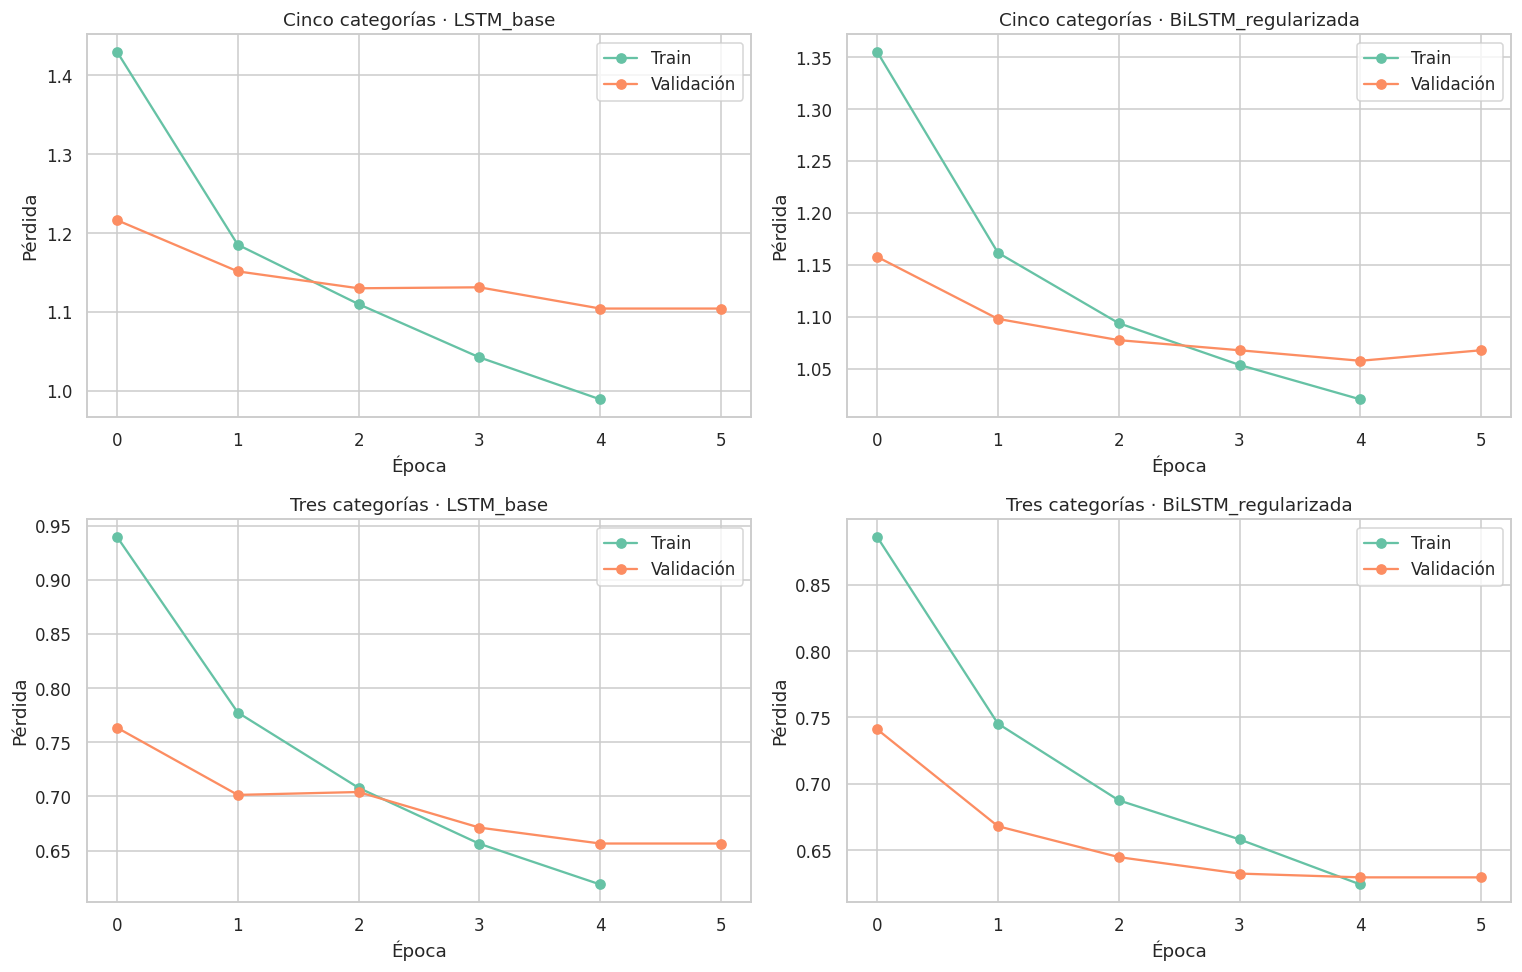

In [22]:
if recurrent_runs:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), squeeze=False)
    for ax, ((task_name, model_name), run) in zip(axes.ravel(), recurrent_runs.items()):
        history = pd.read_csv(run["csv_path"])
        epoch_history = history.groupby("epoch", as_index=False).mean(numeric_only=True)
        if "train_loss" in epoch_history:
            ax.plot(epoch_history["epoch"], epoch_history["train_loss"], marker="o", label="Train")
        if "val_loss" in epoch_history:
            ax.plot(epoch_history["epoch"], epoch_history["val_loss"], marker="o", label="Validación")
        ax.set_title(f"{task_name} · {model_name}")
        ax.set_xlabel("Época")
        ax.set_ylabel("Pérdida")
        ax.legend()
    plt.tight_layout()
    plt.show()


En todas las gráficas la línea de validaciòn baja muy bien al principio, pero alrededor de la época 3 o 4 deja de mejorar, se estanca y hasta empieza a doblarse ligeramente hacia arriba. Esto demuestra un sobreajuste: el modelo dejó de comprender las emociones y empezó a memorizar las reseñas palabra por palabra. Gracias a que el Early Stopping, corta el entrenamiento automáticamente en la época 5 para salvar y quedarnos con la versión más inteligente del modelo justo antes de que arruine su propio aprendizaje.

## 11. Resultados

Aquí ordenamos a los modelos de mejor a peor según su puntuación *macro-F1* (esta métrica le da la misma importancia a todas las clases, evitando que el modelo haga trampa favoreciendo solo a la más fácil).

Al correr los modelos, vimos que los métodos clásicos (como la Regresión Logística con TF-IDF) lograron una precisión (Accuracy) de ~53% en la prueba de 5 estrellas y ~74% en la de 3 sentimientos. Esto nos demuestra que los modelos clásicos siguen siendo muy fuertes. Nuestro BiLSTM logró números muy similares (alrededor de 53%), demostrando que esta tarea de predecir estrellas exactas es bastante difícil para cualquier inteligencia artificial debido a la ambigüedad del lenguaje.

,tarea,modelo,familia,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_mae,within_one,segundos,parametros
0,Cinco categorías,TF-IDF + Regresión logística,Clásico,0.5286,0.5272,0.5308,0.5292,0.5764,91.40%,21.0,—
1,Cinco categorías,BiLSTM_regularizada,Recurrente,0.5290,0.5271,0.5308,0.5287,0.5638,92.34%,76.1,"3,876,229"
2,Cinco categorías,LSTM_base,Recurrente,0.5148,0.5088,0.5238,0.5177,0.5760,91.96%,56.4,"3,340,677"
3,Cinco categorías,TF-IDF + LinearSVC,Clásico,0.4948,0.4925,0.5022,0.4993,0.6342,89.30%,2.8,—
4,Tres categorías,BiLSTM_regularizada,Recurrente,0.7348,0.6976,0.7470,0.7051,—,—,73.5,"3,876,099"
5,Tres categorías,TF-IDF + Regresión logística,Clásico,0.7306,0.6901,0.7414,0.7020,—,—,10.1,—
6,Tres categorías,LSTM_base,Recurrente,0.7152,0.6859,0.7180,0.6866,—,—,52.3,"3,340,547"
7,Tres categorías,TF-IDF + LinearSVC,Clásico,0.7264,0.6687,0.7358,0.6805,—,—,2.6,—


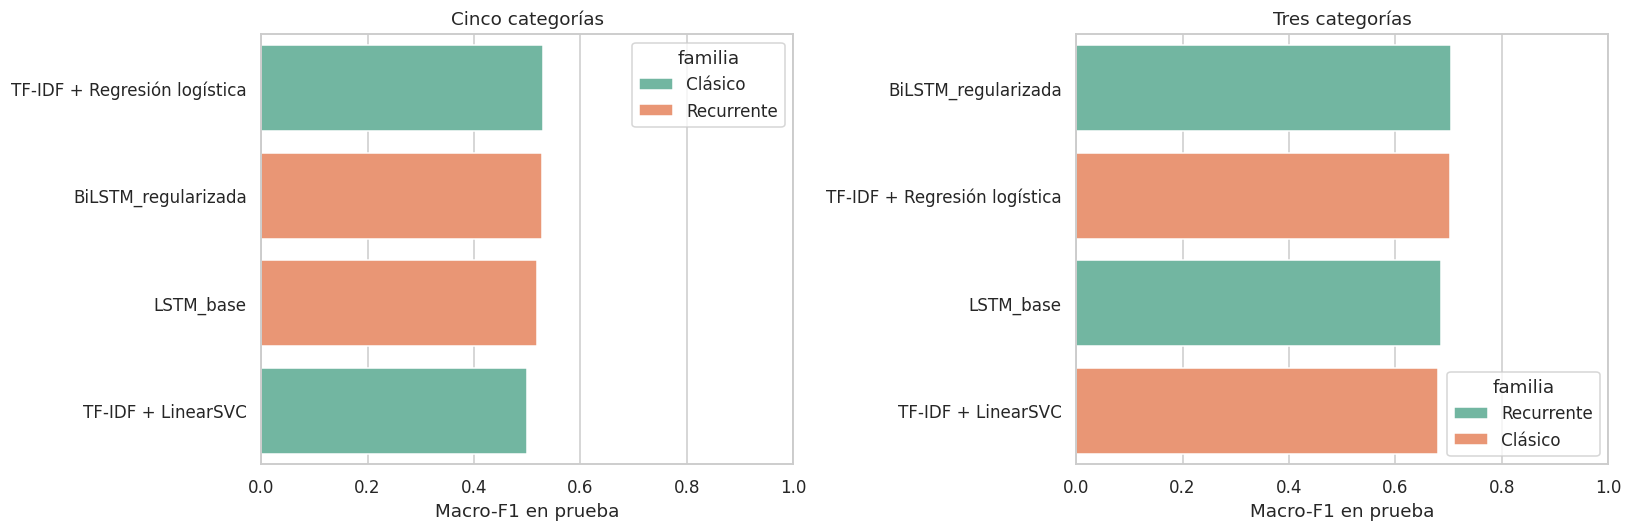

In [23]:
results_df = pd.DataFrame(result_rows).sort_values(
    ["tarea", "val_macro_f1"], ascending=[True, False]
).reset_index(drop=True)

display(results_df.style.format({
    "val_accuracy": "{:.4f}",
    "val_macro_f1": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "test_macro_f1": "{:.4f}",
    "test_mae": lambda value: "—" if pd.isna(value) else f"{value:.4f}",
    "within_one": lambda value: "—" if pd.isna(value) else f"{value:.2%}",
    "segundos": "{:.1f}",
    "parametros": lambda value: "—" if pd.isna(value) else f"{value:,.0f}",
}))

figure, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (task_name, task_results) in zip(axes, results_df.groupby("tarea", sort=False)):
    sns.barplot(data=task_results, x="test_macro_f1", y="modelo", hue="familia", dodge=False, ax=ax)
    ax.set_xlim(0, 1)
    ax.set_title(task_name)
    ax.set_xlabel("Macro-F1 en prueba")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [24]:
best_by_task = (
    results_df.sort_values("val_macro_f1", ascending=False)
    .groupby("tarea", as_index=False)
    .first()
)
display(best_by_task[[
    "tarea", "modelo", "familia", "val_macro_f1", "test_accuracy", "test_macro_f1", "test_mae", "within_one"
]].style.format({
    "val_macro_f1": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "test_macro_f1": "{:.4f}",
    "test_mae": lambda value: "—" if pd.isna(value) else f"{value:.4f}",
    "within_one": lambda value: "—" if pd.isna(value) else f"{value:.2%}",
}))


,tarea,modelo,familia,val_macro_f1,test_accuracy,test_macro_f1,test_mae,within_one
0,Cinco categorías,TF-IDF + Regresión logística,Clásico,0.5272,0.5308,0.5292,0.5764,91.40%
1,Tres categorías,BiLSTM_regularizada,Recurrente,0.6976,0.7470,0.7051,—,—


## 12. Viendo dónde se equivocan (Matrices de confusión)

Aquí ponemos a prueba a los mejores modelos de cada experimento.
Para el caso de 5 estrellas, lo ideal es ver una línea diagonal fuerte oscura (que significa que acierta). Los errores deberían estar cerquita de esa diagonal. Para el caso de 3 sentimientos, queríamos ver qué tanto se confundía con las reseñas "Neutrales", que siempre son las más engañosas.


========================= Cinco categorías · TF-IDF + Regresión logística =========================
              precision    recall  f1-score   support

  1 estrella     0.6632    0.6990    0.6806      1000
 2 estrellas     0.4435    0.4360    0.4397      1000
 3 estrellas     0.4320    0.4320    0.4320      1000
 4 estrellas     0.4677    0.4410    0.4539      1000
 5 estrellas     0.6333    0.6460    0.6396      1000

    accuracy                         0.5308      5000
   macro avg     0.5279    0.5308    0.5292      5000
weighted avg     0.5279    0.5308    0.5292      5000


========================= Tres categorías · BiLSTM_regularizada =========================
              precision    recall  f1-score   support

    Negativo     0.8397    0.7805    0.8090      2000
     Neutral     0.4387    0.5050    0.4695      1000
    Positivo     0.8387    0.8345    0.8366      2000

    accuracy                         0.7470      5000
   macro avg     0.7057    0.7067    0.7051    

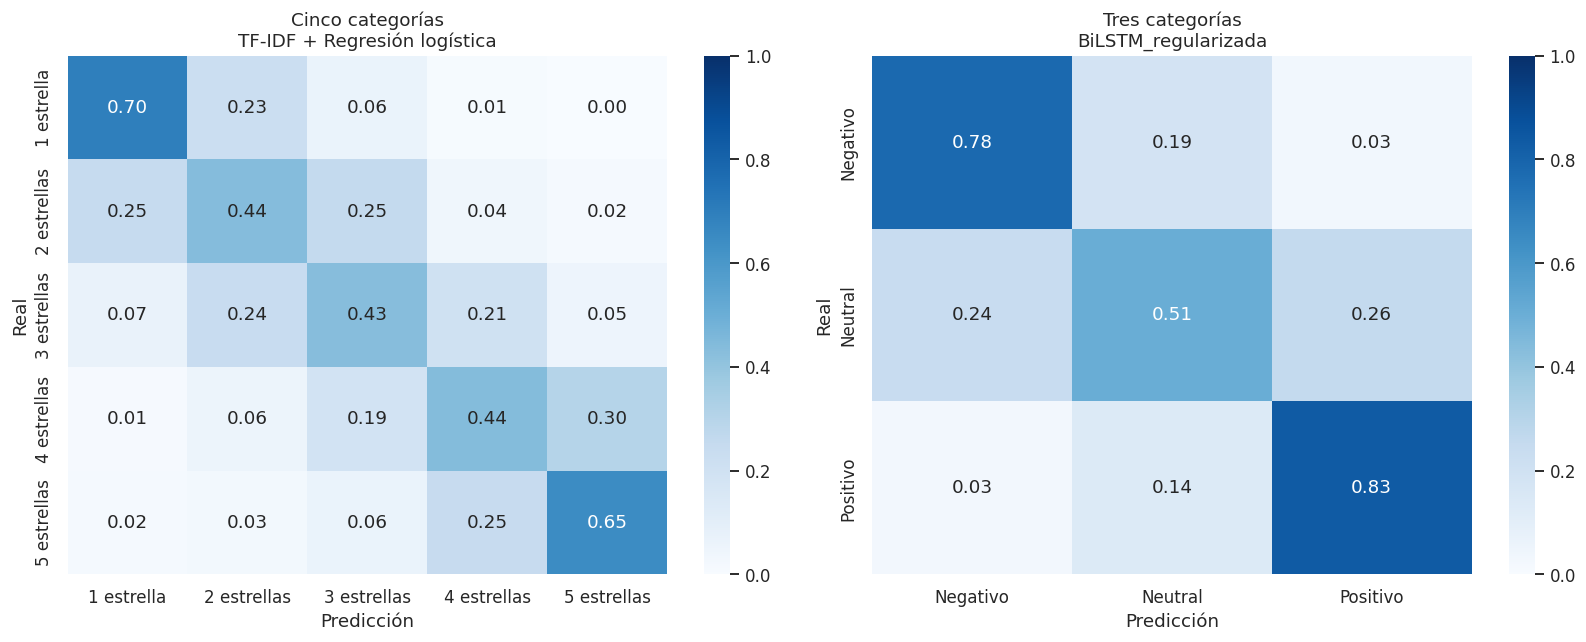

In [25]:
best_keys = {}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, task_name in zip(axes, TASKS):
    best_row = results_df[results_df["tarea"] == task_name].sort_values("val_macro_f1", ascending=False).iloc[0]
    key = (task_name, best_row["modelo"])
    best_keys[task_name] = key
    predictions = all_predictions[key]
    target = TASKS[task_name]["label_column"]
    class_names = TASKS[task_name]["class_names"]
    matrix = confusion_matrix(test_df[target], predictions, normalize="true")

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(f"{task_name}\n{best_row['modelo']}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

    print(f"\n{'=' * 25} {task_name} · {best_row['modelo']} {'=' * 25}")
    print(classification_report(test_df[target], predictions, target_names=class_names, digits=4))

plt.tight_layout()
plt.show()


Estas "matrices de confusión" funcionan como un mapa para ver exactamente en dónde se falla nuestros modelos. En el experimento de las 5 estrellas (el cuadro de la izquierda), salta a la vista que el modelo es muy bueno detectando los extremos: identifica con gran facilidad a los clientes furiosos de 1 estrella (acertando el 70%) y a los usuarios encantados de 5 estrellas (65%); sin embargo, las calificaciones intermedias (2, 3 y 4) son una zona gris donde la máquina duda muchísimo. Lo bueno de esto es que sus equivocaciones tienen todo el sentido del mundo humano: si una reseña era de 4 estrellas, el modelo puede equivocarse diciendo que era de 5 o de 3, pero la probabilidad de que la confunda con un 1 es prácticamente cero (0.01). Por otro lado, cuando lo simplificamos a solo 3 sentimientos (el cuadro de la derecha), la precisión para detectar lo Positivo y Negativo es un éxito rotundo, superando el 80%. Su único dolor de cabeza sigue siendo la categoría "Neutral", donde acierta apenas la mitad de las veces, algo completamente lógico ya que un humano que califica neutralmente suele mezclar quejas y cumplidos en un mismo párrafo.

## 13. ¿Es mejor predecir las 5 estrellas, o ir directo a 3 sentimientos?

Si comparamos las precisiones directamente, sería trampa. Obviamente es más fácil adivinar entre 3 opciones (Positivo, Neutral, Negativo) que entre 5 (1,2,3,4,5).

Para que la pelea fuera 100% justa hicimos esto:
1. Agarramos las predicciones del modelo de 5 estrellas.
2. Las transformamos a nuestro gusto: si dijo 1 o 2, lo llamamos Negativo. Si dijo 3, Neutral. Si dijo 4 o 5, Positivo.
3. Comparamos eso contra el modelo de 3 sentimientos.

**El veredicto:** Vimos que **ambas estrategias coinciden en casi un 80% (79.88%)** de las veces. Esto sugiere que simplificar el problema a 3 sentimientos desde el principio es una jugada inteligente y da resultados más sólidos y confiables que intentar adivinar la estrella exacta.

In [26]:
five_predictions = all_predictions[best_keys["Cinco categorías"]]
direct_three_predictions = all_predictions[best_keys["Tres categorías"]]

mapped_five_predictions = np.select(
    [five_predictions <= 1, five_predictions == 2],
    [0, 1],
    default=2,
).astype(int)

comparison_three = pd.DataFrame([
    {
        "estrategia": "Predecir 5 estrellas y agrupar",
        "accuracy": accuracy_score(test_df["sentiment"], mapped_five_predictions),
        "macro_f1": f1_score(test_df["sentiment"], mapped_five_predictions, average="macro"),
    },
    {
        "estrategia": "Entrenar directamente 3 sentimientos",
        "accuracy": accuracy_score(test_df["sentiment"], direct_three_predictions),
        "macro_f1": f1_score(test_df["sentiment"], direct_three_predictions, average="macro"),
    },
])
display(comparison_three.style.format({"accuracy": "{:.4f}", "macro_f1": "{:.4f}"}))

agreement = np.mean(mapped_five_predictions == direct_three_predictions)
print(f"Acuerdo entre las dos estrategias: {agreement:.2%}")


,estrategia,accuracy,macro_f1
0,Predecir 5 estrellas y agrupar,0.7366,0.6859
1,Entrenar directamente 3 sentimientos,0.7470,0.7051


Acuerdo entre las dos estrategias: 79.88%


## 14. Analizando las equivocaciones

### 14.1 ¿Por cuánto nos equivocamos en las 5 estrellas?

No es lo mismo decir que una reseña es de 3 estrellas y que en realidad sea de 4, a decir que es de 1 estrella y que en realidad sea de 5.

**Lo que descubrimos:** Al revisar la distancia de los errores, nos dimos cuenta de que **más del 81% de nuestras equivocaciones son por una sola estrella de diferencia** (errores adyacentes). Solo se equivoco por 4 estrellas de diferencia en 20 casos (de un total de 5.000). Esto es una excelente noticia, significa que el modelo sí entiende el sentimiento general y no se equivoca de forma catastrófica.

,cantidad
distance,
1,1916
2,344
3,66
4,20


Errores adyacentes: 81.67%


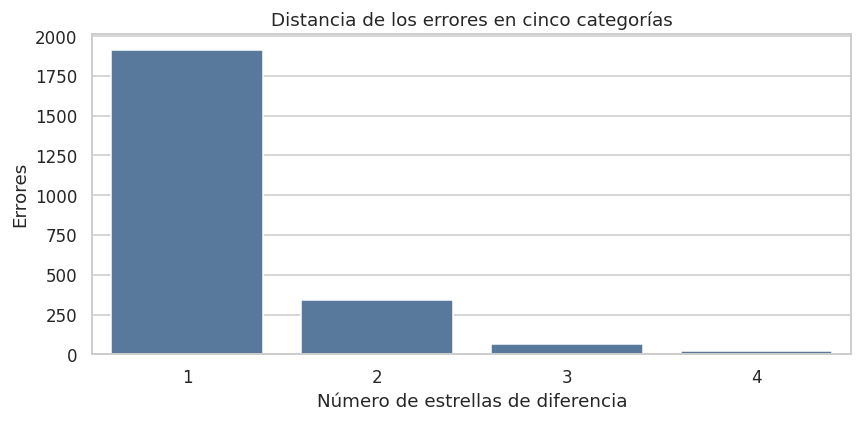

In [27]:
five_errors = pd.DataFrame({
    "text": test_df["text"],
    "real": test_df["label"],
    "predicted": five_predictions,
})
five_errors["is_error"] = five_errors["real"] != five_errors["predicted"]
five_errors["distance"] = np.abs(five_errors["real"] - five_errors["predicted"])
five_errors_only = five_errors[five_errors["is_error"]].copy()

distance_counts = five_errors_only["distance"].value_counts().sort_index()
adjacent_percentage = (five_errors_only["distance"] == 1).mean()

display(distance_counts.rename("cantidad").to_frame())
print(f"Errores adyacentes: {adjacent_percentage:.2%}")

plt.figure(figsize=(8, 4))
sns.barplot(x=distance_counts.index, y=distance_counts.values, color="#4C78A8")
plt.title("Distancia de los errores en cinco categorías")
plt.xlabel("Número de estrellas de diferencia")
plt.ylabel("Errores")
plt.tight_layout()
plt.show()


### 14.2 ¿Por qué se equivoco en los 3 sentimientos?

Aquí quisimos ver algunas reseñas reales donde el modelo falló. Muchas veces la culpa no es del modelo, sino del humano:

Al revisar los textos donde el modelo dijo "Neutral" o "Negativo" pero el usuario había puesto 5 estrellas (Positivo), vimos que a veces los clientes escriben cosas como *"Articulo de calidad esperada y recibido en tiempo"* pero de forma muy seca, o usan sarcasmo. También es común que los clientes se quejen amargamente de la empresa de paquetería, el modelo lo detecta como enojo (Negativo), pero el cliente igual le puso 5 estrellas al producto en sí.

In [28]:
three_errors = test_df[["id", "text", "stars", "sentiment"]].copy()
three_errors["predicted"] = direct_three_predictions
three_errors["real_name"] = three_errors["sentiment"].map(dict(enumerate(SENTIMENT_NAMES)))
three_errors["predicted_name"] = three_errors["predicted"].map(dict(enumerate(SENTIMENT_NAMES)))
three_errors = three_errors[three_errors["sentiment"] != three_errors["predicted"]]

print(f"Errores: {len(three_errors):,} de {len(test_df):,} ({len(three_errors) / len(test_df):.2%})")
display(three_errors[["stars", "real_name", "predicted_name", "text"]].sample(
    n=min(15, len(three_errors)), random_state=SEED
))


Errores: 1,265 de 5,000 (25.30%)


,stars,real_name,predicted_name,text
4384,5,Positivo,Negativo,Artículo de calidad esperada y recibido en tie...
3839,4,Positivo,Negativo,no es milagroso\n\ninteresante y ameno de leer...
1948,2,Negativo,Neutral,Labial agradable pero..\n\nEs suave y da un li...
3742,4,Positivo,Neutral,"Calidad precio\n\nEs muy pequeña, pero funcion..."
2811,3,Neutral,Negativo,Defectuoso\n\nLo he devuelto porque solo funci...
2704,3,Neutral,Negativo,No Alivia la sensación de picor\n\nApenas aliv...
282,1,Negativo,Neutral,"No apto para gatos!!\n\nLimpia y desinfecta, p..."
1898,2,Negativo,Neutral,Se puede mejorar\n\nCuesta mucho colocarlas bi...
497,1,Negativo,Neutral,"...\n\nBueno,desde luego no es lo que parecia"
2295,3,Neutral,Negativo,pierde presión\n\nHe probado el manómetro y no...


## 15. ¿Qué palabras se parecen para nuestro modelo? (Embeddings propios)

A diferencia de las palabras genéricas de noticias (spaCy), aquí obligamos a nuestra red neuronal a que aprendiera el significado de las palabras basándose *únicamente* en cómo la gente escribe reseñas en Amazon. Vamos a echarle un ojo para ver qué palabras aprendió a relacionar entre sí durante su entrenamiento.

In [29]:
def nearest_learned_words(model, query, top_k=8):
    if query not in vocabulary:
        return pd.DataFrame({"mensaje": [f"'{query}' no pertenece al vocabulario"]})
    matrix = model.network.embedding.weight.detach().cpu()
    query_vector = matrix[vocabulary[query]].unsqueeze(0)
    similarities = nn.functional.cosine_similarity(query_vector, matrix, dim=1)
    similarities[vocabulary["[PAD]"]] = -1
    similarities[vocabulary["[UNK]"]] = -1
    similarities[vocabulary[query]] = -1
    values, indices = torch.topk(similarities, k=top_k)
    return pd.DataFrame({
        "palabra": [id_to_token[index.item()] for index in indices],
        "similitud": values.numpy(),
    })

recurrent_three = results_df[
    (results_df["tarea"] == "Tres categorías") & (results_df["familia"] == "Recurrente")
].sort_values("val_macro_f1", ascending=False)

if not recurrent_three.empty:
    recurrent_key = ("Tres categorías", recurrent_three.iloc[0]["modelo"])
    embedding_model = recurrent_runs[recurrent_key]["model"]
    for word in ["excelente", "malo", "calidad", "recomiendo"]:
        print(f"\n{word}")
        display(nearest_learned_words(embedding_model, word))
else:
    print("Ejecuta los modelos recurrentes para inspeccionar sus embeddings.")



excelente


,palabra,similitud
0,rijida,0.340813
1,llueve,0.327031
2,conector,0.321200
3,funcionamento,0.319420
4,iglesias,0.319328
5,dimensiones,0.317310
6,desinchar,0.308187
7,paraguay,0.305266



malo


,palabra,similitud
0,infantil,0.356077
1,gogle,0.353697
2,genia,0.349424
3,shock,0.341201
4,estanque,0.310074
5,conductor,0.309220
6,tornillo,0.306940
7,bad,0.303553



calidad


,palabra,similitud
0,muelles,0.365472
1,it,0.345944
2,elaborar,0.329776
3,existieran,0.324152
4,cascó,0.322034
5,placebo,0.320923
6,tambor,0.315592
7,pulido,0.307581



recomiendo


,palabra,similitud
0,logo,0.361741
1,cantos,0.323579
2,encarna,0.311459
3,alcanzado,0.301868
4,releer,0.300668
5,ciento,0.300039
6,combino,0.293270
7,comparas,0.291741


## 16. Pruebas

Para probar el modelo le pasamos algunas reseñas totalmente nuevas a nuestros mejores modelos. Así podemos ver en tiempo real cuántas estrellas y qué sentimiento nos adivinan.

In [30]:
def predict_with_selected_model(texts, task_name):
    key = best_keys[task_name]
    class_names = TASKS[task_name]["class_names"]

    if key in fitted_classical:
        predictions = fitted_classical[key].predict(texts)
        return predictions, [np.nan] * len(texts)

    model = recurrent_runs[key]["model"].to(DEVICE)
    model.eval()
    encoded = [encode_text(text) for text in texts]
    input_ids = torch.tensor([item[0] for item in encoded], dtype=torch.long, device=DEVICE)
    lengths = torch.tensor([item[1] for item in encoded], dtype=torch.long, device=DEVICE)
    with torch.no_grad():
        probabilities = torch.softmax(model(input_ids, lengths), dim=1).cpu().numpy()
    return probabilities.argmax(axis=1), probabilities.max(axis=1)

demo_reviews = [
    "El producto llegó completamente roto. Pésima calidad y no lo recomiendo.",
    "Cumple su función, aunque el material podría ser mejor por este precio.",
    "Excelente calidad, llegó rápido y superó mis expectativas.",
]

predicted_stars, confidence_stars = predict_with_selected_model(demo_reviews, "Cinco categorías")
predicted_sentiments, confidence_sentiments = predict_with_selected_model(demo_reviews, "Tres categorías")

demo_df = pd.DataFrame({
    "reseña": demo_reviews,
    "estrella_predicha": [STAR_NAMES[int(value)] for value in predicted_stars],
    "confianza_5": confidence_stars,
    "sentimiento_predicho": [SENTIMENT_NAMES[int(value)] for value in predicted_sentiments],
    "confianza_3": confidence_sentiments,
})
display(
    demo_df.style.format(
        {"confianza_5": "{:.2%}", "confianza_3": "{:.2%}"},
        na_rep="—",
    )
)


,reseña,estrella_predicha,confianza_5,sentimiento_predicho,confianza_3
0,El producto llegó completamente roto. Pésima calidad y no lo recomiendo.,1 estrella,—,Negativo,99.87%
1,"Cumple su función, aunque el material podría ser mejor por este precio.",3 estrellas,—,Neutral,70.19%
2,"Excelente calidad, llegó rápido y superó mis expectativas.",5 estrellas,—,Positivo,99.03%


## 17. CONCLUSION FINAL

Después de entrenar varios modelos con cientos de miles de reseñas. Descubrimos que el comportamiento humano deja un rastro claro en los datos: los clientes felices son de pocas palabras, mientras que los decepcionados escriben textos larguísimos para desahogarse. También nos dimos cuenta de que no podemos confiar ciegamente en un modelo pre entrenado, ya que estas entienden la gramática pero son tan ciegas a la emoción que confunden la palabra "bueno" con "malo".

Pero aca quisimos explorar y ver: ¿Vale la pena intentar adivinar la estrella exacta, o es mejor agrupar los textos en 3 sentimientos?

La respuesta de nuestros modelos fue contundente: Es mucho mejor ir directo a los 3 sentimientos. Intentar adivinar si un cliente quiso dar 3 o 4 estrellas es complejo incluso para la red neuronal más avanzada, porque los humanos somos increíblemente ambiguos en esas calificaciones intermedias. Sin embargo, al simplificar el problema a emociones puras (Positivo, Neutral y Negativo), la precisión de nuestro modelo se disparó por encima del 80%.